Initialized MLflow to track repo "Dekhsa/Project-TimeseriesHargaCabai"

Repository Dekhsa/Project-TimeseriesHargaCabai initialized!

2026/05/03 23:12:58 INFO mlflow.tracking.fluent: Experiment with name 'Analisis_Harga_Cabai_Rolling' does not exist. Creating a new experiment.


Training GradientBoosting...
Training SARIMAX (Rolling Forecast)...


c:\Users\62812\miniconda3\envs\data-science\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\62812\miniconda3\envs\data-science\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\62812\miniconda3\envs\data-science\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\62812\miniconda3\envs\data-science\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\62812\miniconda

MAPE GradientBoosting: 2.12%
MAPE SARIMAX: 1.64%


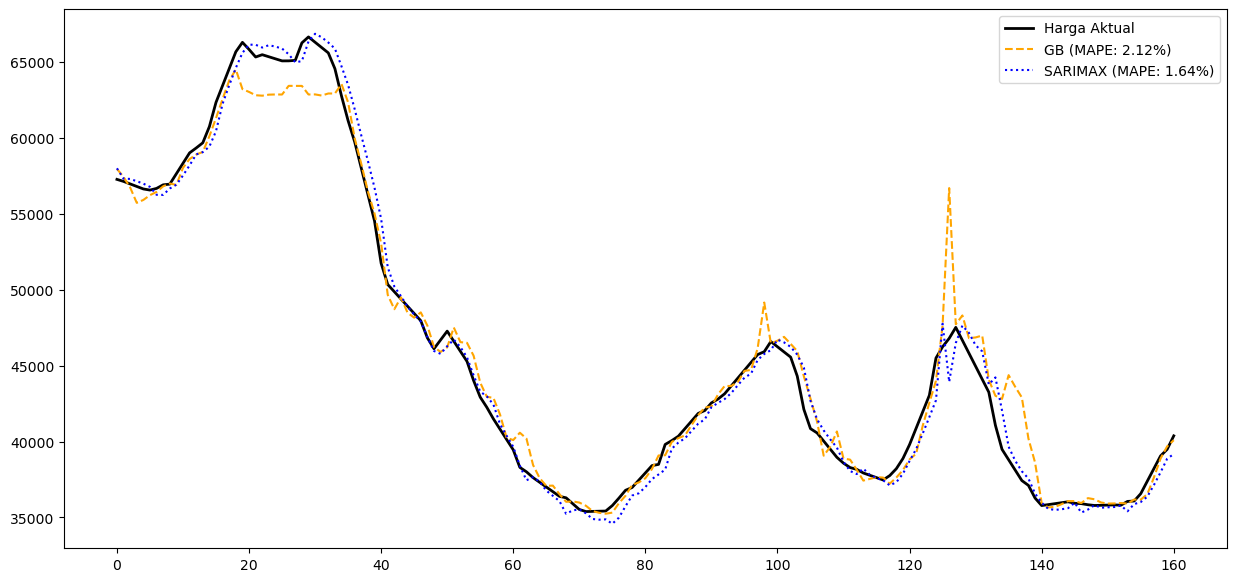

c:\Users\62812\miniconda3\envs\data-science\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run GB_vs_SARIMAX_Final at: https://dagshub.com/Dekhsa/Project-TimeseriesHargaCabai.mlflow/#/experiments/1/runs/ffc4d479787c44b7874a7e101ac02e16
🧪 View experiment at: https://dagshub.com/Dekhsa/Project-TimeseriesHargaCabai.mlflow/#/experiments/1
Tracking MLflow selesai. Silakan cek dashboard Dagshub Anda.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error as mape
import mlflow
import mlflow.sklearn
import mlflow.statsmodels
import mlflow.models
import dagshub

# 1. INISIALISASI DAGSHUB & MLFLOW
# Pastikan repo 'Project-TimeseriesHargaCabai' sudah ada di akun Dagshub 'Dekhsa'
dagshub.init(repo_owner='Dekhsa', repo_name='Project-TimeseriesHargaCabai', mlflow=True)
mlflow.set_experiment("Analisis_Harga_Cabai_Rolling")

# Start MLflow run
with mlflow.start_run(run_name="GB_vs_SARIMAX_Final"):
    # Log experiment description
    mlflow.log_param("experiment_description", "Comparison of GradientBoosting and SARIMAX Rolling Forecast")
    
    # 2. PREPARASI DATA
    # Mengasumsikan file ada di path relatif berikut
    df = pd.read_csv('../../data/processed/data_with_holidays.csv')
    df['tanggal_data'] = pd.to_datetime(df['tanggal_data'])
    df = df.sort_values('tanggal_data')

    # Label Encoding 'jenis_libur'
    df['jenis_libur'] = df['jenis_libur'].fillna('Bukan Libur')
    le = LabelEncoder()
    df['jenis_libur_encoded'] = le.fit_transform(df['jenis_libur'])

    # Ubah 'is_libur' ke integer
    df['is_libur'] = df['is_libur'].astype(int)

    # Handling Gap Tanggal & Interpolasi
    full_range = pd.date_range(df['tanggal_data'].min(), df['tanggal_data'].max(), freq='D')
    df = df.set_index('tanggal_data').reindex(full_range)
    df['harga'] = df['harga'].interpolate(method='linear')
    df['is_libur'] = df['is_libur'].fillna(0).astype(int)
    df['jenis_libur_encoded'] = df['jenis_libur_encoded'].fillna(le.transform(['Bukan Libur'])[0]).astype(int)

    # 3. PEMBUATAN DATASET WINDOW
    def create_window_dataset(data, window_size, horizon):
        X, y = [], []
        prices = data['harga'].values
        libur_bin = data['is_libur'].values
        libur_type = data['jenis_libur_encoded'].values
        for i in range(len(data) - window_size - horizon + 1):
            window_prices = prices[i : i + window_size]
            target_holiday_bin = libur_bin[i + window_size + horizon - 1]
            target_holiday_type = libur_type[i + window_size + horizon - 1]
            features = np.append(window_prices, [target_holiday_bin, target_holiday_type])
            X.append(features)
            y.append(prices[i + window_size + horizon - 1])
        return np.array(X), np.array(y)

    WINDOW = 7
    HORIZON = 1
    X, y = create_window_dataset(df, WINDOW, HORIZON)

    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Log dataset parameters
    mlflow.log_params({
        "window_size": WINDOW,
        "horizon": HORIZON,
        "train_split_ratio": 0.8,
        "total_samples": len(X)
    })

    # 4. MODEL 1: GRADIENT BOOSTING
    print("Training GradientBoosting...")
    model_gb = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
    model_gb.fit(X_train, y_train)
    pred_gb = model_gb.predict(X_test)

    mlflow.log_params({
        "gb_n_estimators": 500,
        "gb_learning_rate": 0.05,
        "gb_max_depth": 6
    })

    # 5. MODEL 2: SARIMAX (ROLLING FORECAST)
    print("Training SARIMAX (Rolling Forecast)...")
    train_df = df.iloc[:split + WINDOW]
    test_df = df.iloc[split + WINDOW :]

    history_price = list(train_df['harga'])
    history_exog = train_df[['is_libur', 'jenis_libur_encoded']].values.tolist()
    pred_sarima_rolling = []

    mlflow.log_param("sarimax_order", "(1, 1, 1)")

    for i in range(len(test_df)):
        try:
            model_s = SARIMAX(history_price, 
                              exog=history_exog, 
                              order=(1, 1, 1), 
                              seasonal_order=(1, 1, 1, 7),
                              enforce_stationarity=False,
                              enforce_invertibility=False)
            
            model_s_fit = model_s.fit(disp=False, maxiter=200, method='nm') 
            
            curr_exog = [test_df[['is_libur', 'jenis_libur_encoded']].iloc[i].values]
            out = model_s_fit.forecast(steps=1, exog=curr_exog)
            pred_sarima_rolling.append(out[0])
            
        except Exception as e:
            pred_sarima_rolling.append(history_price[-1])
            
        history_price.append(test_df['harga'].iloc[i])
        history_exog.append(test_df[['is_libur', 'jenis_libur_encoded']].iloc[i].values.tolist())

    # 6. EVALUASI & VISUALISASI
    mape_gb = mape(y_test, pred_gb) * 100
    mape_sarima = mape(y_test, pred_sarima_rolling) * 100

    mlflow.log_metrics({
        "MAPE_GradientBoosting": mape_gb,
        "MAPE_SARIMAX": mape_sarima
    })

    print(f"MAPE GradientBoosting: {mape_gb:.2f}%")
    print(f"MAPE SARIMAX: {mape_sarima:.2f}%")

    # Plot
    plt.figure(figsize=(15, 7))
    plt.plot(y_test, label='Harga Aktual', color='black', linewidth=2)
    plt.plot(pred_gb, label=f'GB (MAPE: {mape_gb:.2f}%)', color='orange', linestyle='--')
    plt.plot(pred_sarima_rolling, label=f'SARIMAX (MAPE: {mape_sarima:.2f}%)', color='blue', linestyle=':')
    plt.legend()
    
    plot_path = "comparison_plot.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path)
    plt.show()

    # 7. LOG MODELS (API Update: use 'name' and infer signature)
    # Gradient Boosting
    gb_signature = mlflow.models.infer_signature(X_train, model_gb.predict(X_train))
    mlflow.sklearn.log_model(
        sk_model=model_gb, 
        name="gradientboosting_model",
        signature=gb_signature,
        input_example=X_train[:3]
    )

    # SARIMAX (Logging model terakhir dari loop)
    s_signature = mlflow.models.infer_signature(train_df[['is_libur', 'jenis_libur_encoded']], pred_sarima_rolling[:1])
    mlflow.statsmodels.log_model(
        statsmodels_model=model_s_fit, 
        name="sarimax_model",
        signature=s_signature
    )

print("Tracking MLflow selesai. Silakan cek dashboard Dagshub Anda.")